In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np 
from ase.io import read, write
import seaborn as sns
from pymatgen.core import Structure

In [2]:
def cif_string_to_structure(cif_string):
    """Converts a CIF string back to a pymatgen Structure object."""
    if not cif_string.strip():
        return None
    try:
        return Structure.from_str(cif_string, fmt="cif")
    except Exception:
        return None

def structure_to_cif_string(struct):
    """Converts a pymatgen Structure object to a multi-line CIF string."""
    if struct is None:
        return ""
    try:
        return struct.to(fmt="cif")
    except Exception:
        return ""

In [3]:
df = pd.read_csv("merged_data_SUN.csv")
print(df.shape)
df.dropna(inplace=True)
print(df.shape)
df['host_structure'] = df['host_structure'].apply(cif_string_to_structure)
df['cif'] = df['cif'].apply(cif_string_to_structure)
df['Na_structure'] = df['Na_structure'].apply(cif_string_to_structure)

(4180, 18)
(4180, 18)


/home/ilgar/code/miniforge3/envs/meta_eon/lib/python3.10/site-packages/pymatgen/core/structure.py:3107: UserWarning: Issues encountered while parsing CIF: 1 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/ilgar/code/miniforge3/envs/meta_eon/lib/python3.10/site-packages/pymatgen/core/structure.py:3107: UserWarning: Issues encountered while parsing CIF: 2 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/ilgar/code/miniforge3/envs/meta_eon/lib/python3.10/site-packages/pymatgen/core/structure.py:3107: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/ilgar/code/miniforge3/envs/meta_eon/lib/python3.10/site-packages/pymatgen/core/structure

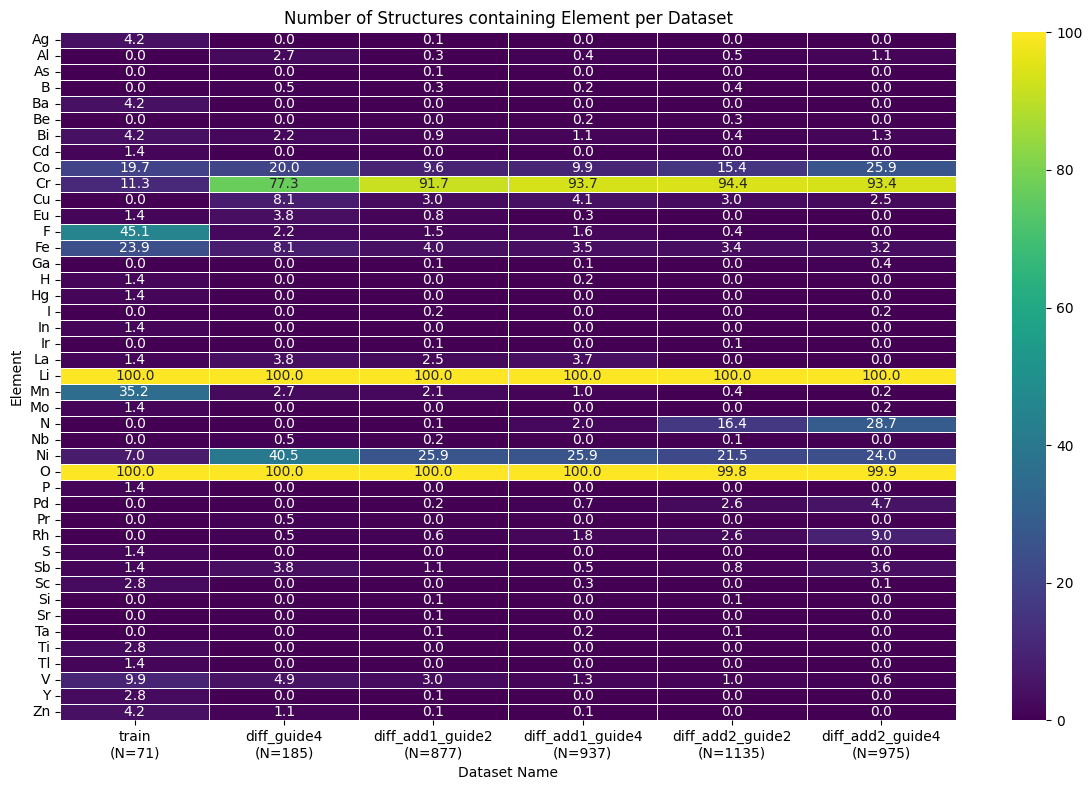

In [4]:
traj = read('merged_data.traj', index=':')

total_counts = pd.Series([atoms.info.get('dataset', 'Unknown') for atoms in traj]).value_counts()

data_list = []

for atoms in traj:
    ds_name = atoms.info.get('dataset', 'Unknown')
    elements = set(atoms.get_chemical_symbols())
    
    for el in elements:
        data_list.append({'Dataset': ds_name, 'Element': el})

df_el_dataset = pd.DataFrame(data_list)
# This creates a table: Rows=Datasets, Cols=Elements, Values=Count
desired_order = ["train", "diff_guide4", "diff_add1_guide2", "diff_add1_guide4", "diff_add2_guide2", "diff_add2_guide4"]
# First get the raw counts (transposed as you requested)
raw_counts = pd.crosstab(df_el_dataset['Element'], df_el_dataset['Dataset']).reindex(columns=desired_order).fillna(0)
# Divide by the total counts to get percentage
heatmap_data = raw_counts.div(total_counts[desired_order], axis=1) * 100

new_labels = [f"{col}\n(N={int(total_counts[col])})" for col in heatmap_data.columns]


plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='viridis', linewidths=.5, xticklabels=new_labels)
plt.title('Number of Structures containing Element per Dataset')
plt.xlabel('Dataset Name')
plt.ylabel('Element')
plt.tight_layout()
plt.savefig('dataset_element_heatmap.png')
plt.show()

In [5]:
def calculate_material_price_per_kg(structure: Structure) -> float:
# def calculate_material_price_per_kg(atoms) -> float:
    prices_usd_per_kg = {
        'H': 1.39,      'He': 24.0,     'Li': 83.5,     'Be': 857.0,    'B': 3.68,
        'C': 0.12,      'N': 0.14,      'O': 0.154,     'F': 2.00,      'Ne': 240.0,
        'Na': 3.00,     'Mg': 2.32,     'Al': 1.79,     'Si': 1.70,     'P': 2.69,
        'S': 0.0926,    'Cl': 0.082,    'Ar': 0.93,     'K': 12.8,      'Ca': 2.28,
        'Sc': 3460.0,   'Ti': 11.4,     'V': 371.0,     'Cr': 9.40,     'Mn': 1.82,
        'Fe': 0.42,     'Co': 32.8,     'Ni': 13.9,     'Cu': 6.00,     'Zn': 2.55,
        'Ga': 148.0,    'Ge': 962.0,    'As': 1.15,     'Se': 21.4,     'Br': 4.39,
        'Kr': 290.0,    'Rb': 15500.0,  'Sr': 6.60,     'Y': 31.0,      'Zr': 36.4,
        'Nb': 73.5,     'Mo': 40.1,     'Ru': 10500.0,  'Rh': 147000.0, 'Pd': 49500.0,
        'Ag': 521.0,    'Cd': 2.73,     'In': 167.0,    'Sn': 18.7,     'Sb': 5.79,
        'Te': 63.5,     'I': 35.0,      'Xe': 1800.0,   'Cs': 61800.0,  'Ba': 0.26,
        'La': 4.85,     'Ce': 4.64,     'Pr': 103.0,    'Nd': 57.5,     'Sm': 13.9,
        'Eu': 31.4,     'Gd': 28.6,     'Tb': 658.0,    'Dy': 307.0,    'Ho': 57.1,
        'Er': 26.4,     'Tm': 3000.0,   'Yb': 17.1,     'Lu': 643.0,    'Hf': 900.0,
        'Ta': 305.0,    'W': 35.3,      'Re': 3580.0,   'Os': 30000.0,  'Ir': 144000.0,
        'Pt': 27800.0,  'Au': 75430.0,  'Hg': 30.2,     'Tl': 4200.0,   'Pb': 2.00,
        'Bi': 6.36
    }
    masses = [site.species.elements[0].atomic_mass for site in structure]
    symbols = [site.species.elements[0] for site in structure]

    total_mass = np.sum(masses)
    total_cost = sum(m * prices_usd_per_kg.get(str(s), 0.0) for m, s in zip(masses, symbols))

    # masses = atoms.get_masses()
    # symbols = atoms.get_chemical_symbols()

    # total_mass = np.sum(masses)
    # total_cost = sum(m * prices_usd_per_kg.get(s, 0.0) for m, s in zip(masses, symbols))

    return total_cost / total_mass

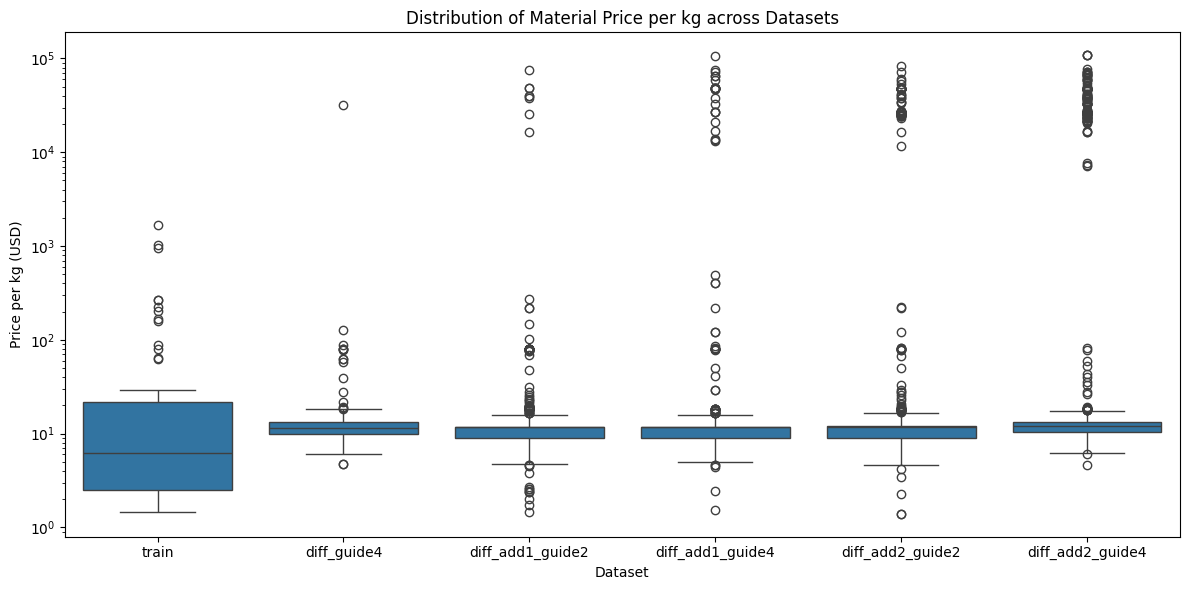

In [6]:
df['price_per_kg'] = df['cif'].apply(calculate_material_price_per_kg)
df_orig = df.copy()
# traj_df['price_per_kg'] = traj_df['atoms'].apply(calculate_material_price_per_kg)
plt.figure(figsize=(12, 6))
sns.boxplot(x='dataset', y='price_per_kg', data=df, order=desired_order)
plt.title('Distribution of Material Price per kg across Datasets')
plt.xlabel('Dataset')
plt.ylabel('Price per kg (USD)')
plt.yscale('log')
# plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('dataset_price_per_kg_boxplot.png')
plt.show()

In [7]:
df = df[df['price_per_kg'] < 30]
print(df.shape)
df.groupby('dataset')['price_per_kg'].describe().reindex(desired_order)

(3872, 19)


,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
train,58.0,7.240014,7.173514,1.462567,2.482445,2.705687,10.779303,29.114819
diff_guide4,174.0,11.437387,3.288638,4.795327,9.684028,11.420526,11.802431,28.016993
diff_add1_guide2,840.0,10.800218,2.880588,1.462567,8.957575,11.420526,11.802431,28.016993
diff_add1_guide4,896.0,10.687790,2.387098,1.520246,8.957575,11.802431,11.802431,29.441462
diff_add2_guide2,1061.0,10.779326,2.668314,1.404241,8.546419,11.802431,12.061200,29.203810
diff_add2_guide4,843.0,11.425576,2.459849,4.631021,9.415606,12.061200,12.061200,27.761255


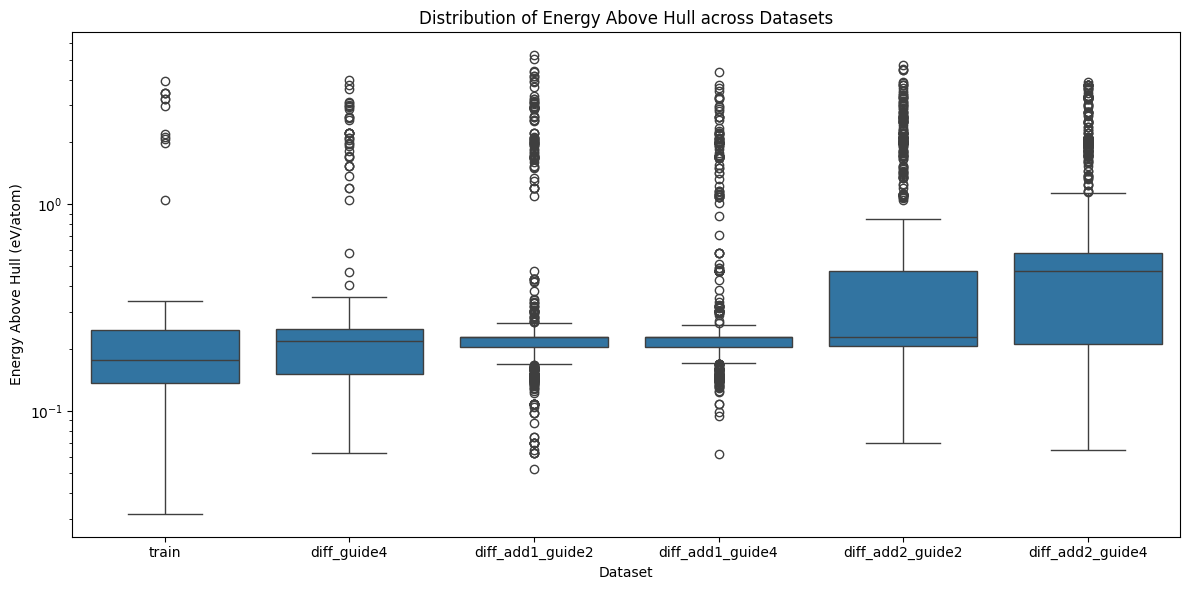

In [8]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='dataset', y='energy_above_hull', data=df, order=desired_order)
plt.title('Distribution of Energy Above Hull across Datasets')
plt.xlabel('Dataset')
plt.ylabel('Energy Above Hull (eV/atom)')
plt.yscale('log')
# plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('dataset_energy_above_hull_boxplot.png')
plt.show()

In [9]:
df = df[df['energy_above_hull'] < 0.15]
print(df.shape)
print("Number of unique stable cheap structures within water window and with voltage difference above 0.7V is ",
      df["unique_group_id"].drop_duplicates().shape[0])
# df.loc[df["unique_group_id"].drop_duplicates().index, "dataset"].to_list()

(498, 19)
Number of unique stable cheap structures within water window and with voltage difference above 0.7V is  77


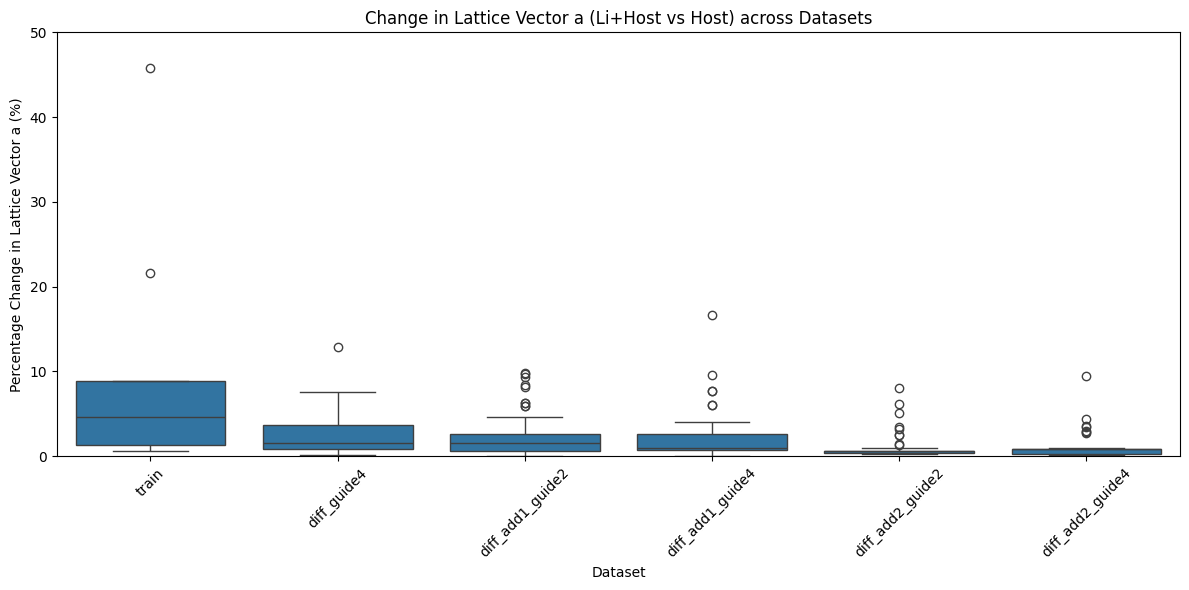

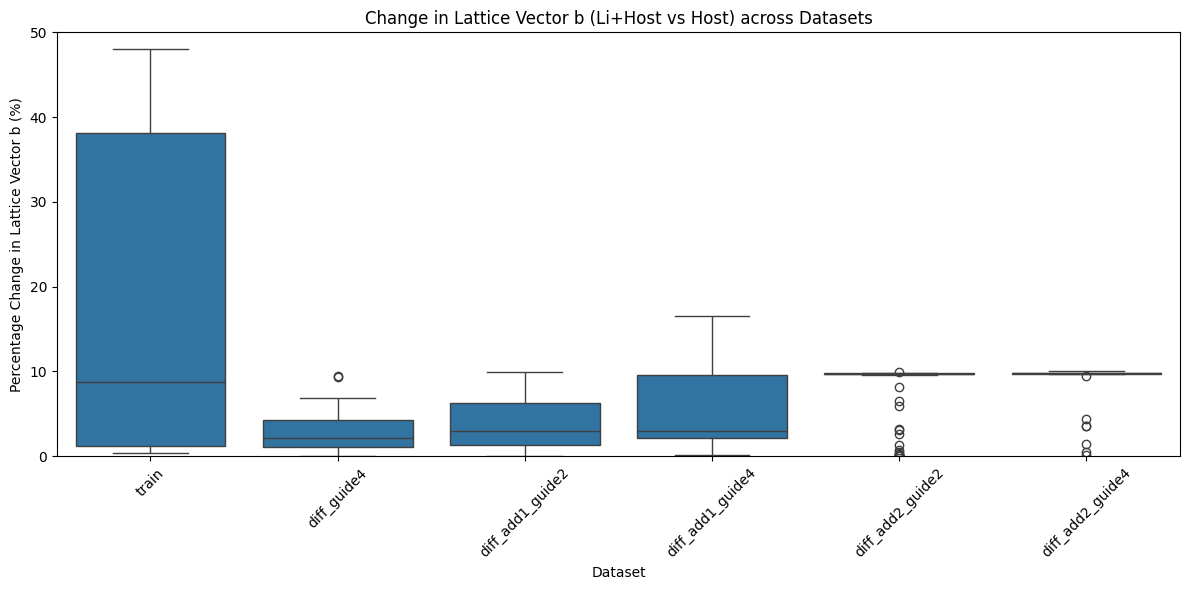

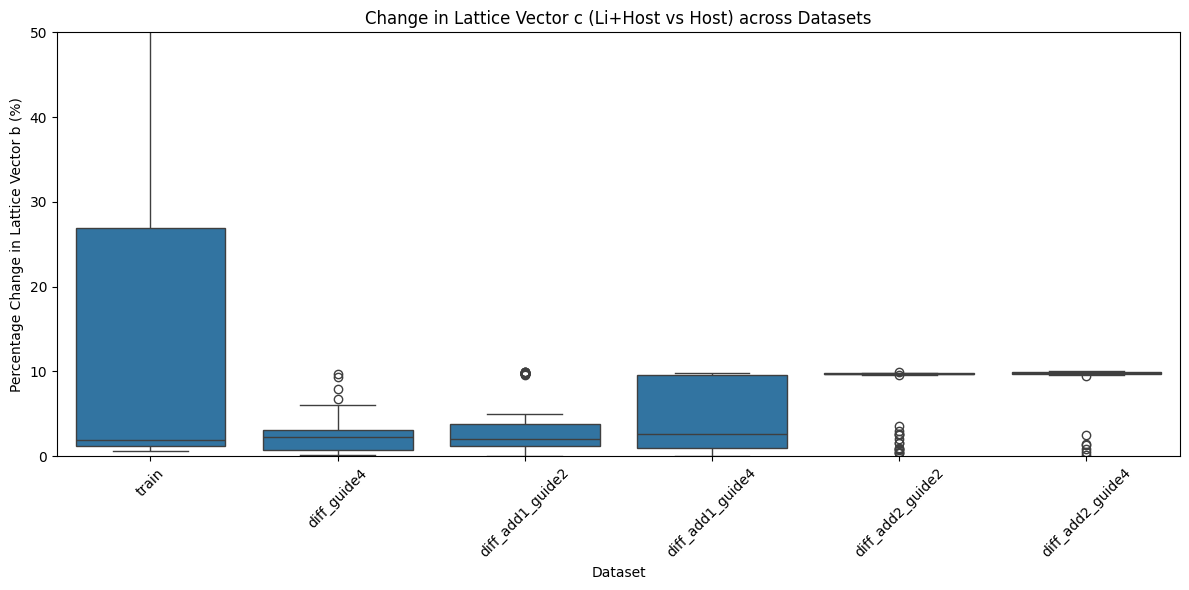

In [10]:
# determine the change in three lattice vectors using the host_structure and the Na_structure and then between host_structure and cif structure
def calculate_lattice_vector_changes(row):
    host = row['host_structure']
    na = row['Na_structure']
    cif = row['cif']

    if host is None or na is None or cif is None:
        return pd.Series([np.nan, np.nan])

    # Get lattice vectors lengths
    host_lattice_lengths = host.lattice.abc
    na_lattice_lengths = na.lattice.abc
    cif_lattice_lengths = cif.lattice.abc

    # Calculate changes of tuples of lengths
    change_na = [np.abs(na_lattice_lengths[i] - host_lattice_lengths[i])/host_lattice_lengths[i]*100 for i in range(3)]
    change_cif = [np.abs(cif_lattice_lengths[i] - host_lattice_lengths[i])/host_lattice_lengths[i]*100 for i in range(3)]

    return pd.Series([change_na[0], change_na[1], change_na[2], change_cif[0], change_cif[1], change_cif[2]])

df[['change_na_a', 'change_na_b', 'change_na_c', 'change_cif_a', 'change_cif_b', 'change_cif_c']] = df.apply(calculate_lattice_vector_changes, axis=1)

# plt.figure(figsize=(12, 6))
# # sns.boxplot(x='dataset', y='change_na_a', data=df_stable, order=desired_order)
# sns.boxplot(x='dataset', y='change_na_a', data=df, order=desired_order)
# plt.title('Change in Lattice Vector a (Na vs Host) across Datasets')
# plt.xlabel('Dataset')
# plt.ylabel('Change in Lattice Vector a (Å)')
# plt.xticks(rotation=45)
# plt.ylim(0, 50)
# plt.tight_layout()
# plt.savefig('dataset_change_na_a_boxplot.png')
# plt.show()
# plt.figure(figsize=(12, 6))
# sns.boxplot(x='dataset', y='change_na_b', data=df, order=desired_order)
# plt.title('Change in Lattice Vector b (Na vs Host) across Datasets')
# plt.xlabel('Dataset')
# plt.ylabel('Change in Lattice Vector b (Å)')
# plt.xticks(rotation=45)
# plt.ylim(0, 50)
# plt.tight_layout()
# plt.savefig('dataset_change_na_b_boxplot.png')
# plt.show()
# plt.figure(figsize=(12, 6))
# sns.boxplot(x='dataset', y='change_na_c', data=df, order=desired_order)
# plt.title('Change in Lattice Vector c (Na vs Host) across Datasets')
# plt.xlabel('Dataset')
# plt.ylabel('Change in Lattice Vector c (Å)')
# plt.xticks(rotation=45)
# plt.ylim(0, 50)
# plt.tight_layout()
# plt.savefig('dataset_change_na_c_boxplot.png')
# plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x='dataset', y='change_cif_a', data=df, order=desired_order)
plt.title('Change in Lattice Vector a (Li+Host vs Host) across Datasets')
plt.xlabel('Dataset')
plt.ylabel('Percentage Change in Lattice Vector a (%)')
plt.xticks(rotation=45)
plt.ylim(0, 50)
plt.tight_layout()
plt.savefig('dataset_change_cif_a_boxplot.png')
plt.show()
plt.figure(figsize=(12, 6))
sns.boxplot(x='dataset', y='change_cif_b', data=df, order=desired_order)
plt.title('Change in Lattice Vector b (Li+Host vs Host) across Datasets')
plt.xlabel('Dataset')
plt.ylabel('Percentage Change in Lattice Vector b (%)')
plt.xticks(rotation=45)
plt.ylim(0, 50)
plt.tight_layout()
plt.savefig('dataset_change_cif_b_boxplot.png')
plt.show()
plt.figure(figsize=(12, 6))
sns.boxplot(x='dataset', y='change_cif_c', data=df, order=desired_order)
plt.title('Change in Lattice Vector c (Li+Host vs Host) across Datasets')
plt.xlabel('Dataset')
plt.ylabel('Percentage Change in Lattice Vector b (%)')
plt.xticks(rotation=45)
plt.ylim(0, 50)
plt.tight_layout()
plt.savefig('dataset_change_cif_c_boxplot.png')
plt.show()


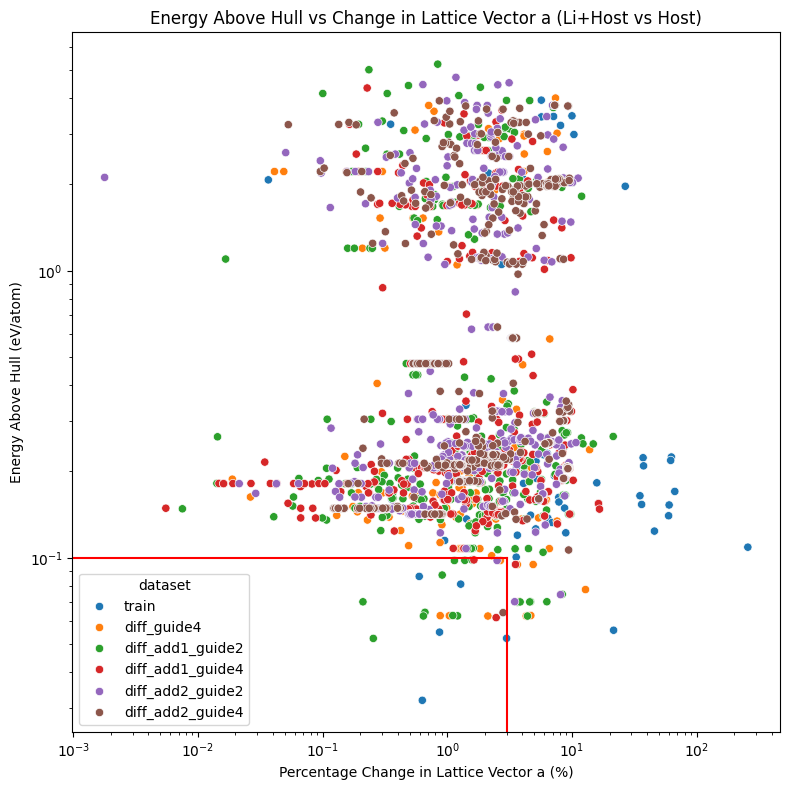

In [28]:
# plot a scatter plot of energy above hull vs percentage change in lattice vector a (Li+Host vs Host) colored by dataset
plt.figure(figsize=(8, 8))
sns.scatterplot(x='change_cif_a', y='energy_above_hull', hue='dataset', data=df)
# add a horizontal line at energy above hull = 0.1 eV/atom until it crosses vertical line (until a=3%)
# and a vertical line at percentage change in lattice vector a = 3% until it crosses vertical line (until 0.1 eV/atom)
plt.plot([0, 3], [0.1, 0.1], 'r-')
plt.plot([3, 3], [0, 0.1], 'r-')
plt.title('Energy Above Hull vs Change in Lattice Vector a (Li+Host vs Host)')
plt.xlabel('Percentage Change in Lattice Vector a (%)')
plt.ylabel('Energy Above Hull (eV/atom)')
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.savefig('energy_above_hull_vs_change_cif_a_scatter.png')
plt.show()


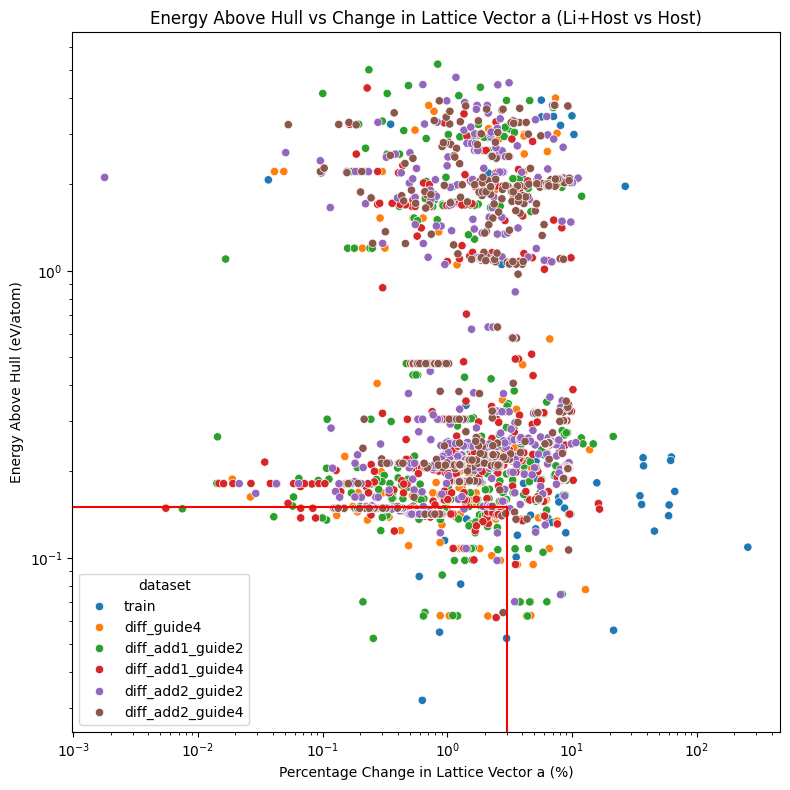

In [27]:
# plot a scatter plot of energy above hull vs percentage change in lattice vector a (Li+Host vs Host) colored by dataset
plt.figure(figsize=(8, 8))
sns.scatterplot(x='change_cif_a', y='energy_above_hull', hue='dataset', data=df)
# add a horizontal line at energy above hull = 0.1 eV/atom until it crosses vertical line (until a=3%)
# and a vertical line at percentage change in lattice vector a = 3% until it crosses vertical line (until 0.1 eV/atom)
plt.plot([0, 3], [0.15, 0.15], 'r-')
plt.plot([3, 3], [0, 0.15], 'r-')
plt.title('Energy Above Hull vs Change in Lattice Vector a (Li+Host vs Host)')
plt.xlabel('Percentage Change in Lattice Vector a (%)')
plt.ylabel('Energy Above Hull (eV/atom)')
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.savefig('energy_above_hull_vs_change_cif_a_scatter.png')
plt.show()


In [11]:
df = df[(df[['change_cif_a', 'change_cif_b', 'change_cif_c']] < 3).all(axis=1)]
print(df.shape)
df['dataset'].value_counts().reindex(desired_order).fillna(0)

(107, 25)


dataset
train                5
diff_guide4         15
diff_add1_guide2    36
diff_add1_guide4    41
diff_add2_guide2     7
diff_add2_guide4     3
Name: count, dtype: int64

In [12]:
df['dataset']

1                  train
25                 train
28                 train
50                 train
64                 train
              ...       
3003    diff_add2_guide2
3190    diff_add2_guide2
3318    diff_add2_guide4
3698    diff_add2_guide4
4012    diff_add2_guide4
Name: dataset, Length: 107, dtype: object

In [13]:
df_sorted = df.sort_values('energy_above_hull')[['dataset','is_novel','energy_above_hull','pretty_formula','unique_group_id','cif']]
df_orig[df_orig['unique_group_id'].isin([234,830])]
# df_sorted

,pretty_formula,material_id,num_atoms,host_energy_per_atom,Li_energy_per_atom,Na_energy_per_atom,Li_voltage,Na_voltage,host_structure,cif,Na_structure,dataset,ID,Li_structure_pymatgen,Li_energy,energy_above_hull,unique_group_id,is_novel,price_per_kg
231,LiCrBiSbO6,gen_724,10.0,-6.473446,-6.305404,-6.122211,-0.150176,-1.058212,"[[4.86610544 2.99607487 0.78144697] Cr, [ 2.33...","[[2.42988024 1.47162961 3.47428712] Li, [5.000...","[[2.52294499 1.47581092 3.49017474] Na, [5.194...",diff_guide4,1743,Full Formula (Li1 Cr1 Bi1 Sb1 O6)\nReduced For...,-63.054042,0.101645,234,1,6.418352
670,LiCrBiSbO6,gen_1885,10.0,-6.473236,-6.342492,-6.174508,0.222592,-0.533348,"[[1.41081478 1.92849129 2.487615 ] Cr, [ 3.89...","[[3.92562972 1.96987381 2.46516044] Li, [1.412...","[[4.06881136 1.98038264 2.4778251 ] Na, [1.462...",diff_add1_guide2,985,Full Formula (Li1 Cr1 Bi1 Sb1 O6)\nReduced For...,-63.424919,0.064557,234,1,6.418352
3698,LiCr4IO10,gen_1922,16.0,-6.715898,-6.644020,-6.501819,0.622654,-0.728669,"[[2.51245374 2.54502557 1.26748774] Cr, [0.241...","[[0.49526486 1.45459043 0.19116414] Li, [2.610...","[[0.28534303 2.13490651 0.49056902] Na, [2.782...",diff_add2_guide4,1027,Full Formula (Li1 Cr4 I1 O10)\nReduced Formula...,-106.304328,0.064398,830,1,13.950955


In [ ]:
df.sort_values('energy_above_hull')

In [12]:
df = df.sort_values('energy_above_hull').drop_duplicates('unique_group_id', keep='first')
print(df.shape)
print(df['dataset'].value_counts().reindex(desired_order).fillna(0))

(36, 25)
dataset
train                5
diff_guide4          4
diff_add1_guide2    15
diff_add1_guide4     5
diff_add2_guide2     4
diff_add2_guide4     3
Name: count, dtype: int64


In [14]:
df['host_structure'] = df['host_structure'].apply(structure_to_cif_string)
df['cif'] = df['cif'].apply(structure_to_cif_string)
df['Na_structure'] = df['Na_structure'].apply(structure_to_cif_string)
df.to_csv("final_filtered_data_all_columns.csv", index=False)
df = df[['pretty_formula','material_id','num_atoms','host_energy_per_atom','Li_energy_per_atom','Na_energy_per_atom','Li_voltage','Na_voltage','host_structure','cif','Na_structure']]
df.rename(columns={"cif": "Li_structure"}, inplace=True)
df.shape

/tmp/user/1016/ipykernel_1955064/2562639950.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={"cif": "Li_structure"}, inplace=True)


(36, 11)

In [16]:
df.iloc[14,:]

pretty_formula                                                LiCr(FeO2)2
material_id                                                        gen_63
num_atoms                                                             8.0
host_energy_per_atom                                            -6.999393
Li_energy_per_atom                                              -6.700083
Na_energy_per_atom                                              -6.487221
Li_voltage                                                      -0.338286
Na_voltage                                                       -1.11728
host_structure                                                           
Li_structure            # generated using pymatgen\ndata_LiCr(FeO2)2\n...
Na_structure            # generated using pymatgen\ndata_NaCr(FeO2)2\n...
Name: 956, dtype: object

In [13]:

df.to_csv("final_filtered_data.csv", index=False)

In [19]:
df_formulas = df['pretty_formula'].copy()
df_formulas.reset_index(drop=True, inplace=True)
df_formulas

0         LiEuCrBiO6
1       LiHg2(BiO3)4
2          LiCr4IO10
3         LiCrBiSbO6
4         LiTi3Zn2O8
5          Li2CrNiO4
6         LiEu2Cr3O8
7           LiCrNiO3
8        LiMn(NiO2)2
9             LiFeO2
10         LiCr3NiO6
11           LiCr4O8
12        LiAl3Cr2O8
13      LiCr4(BiO6)2
14       LiCr(FeO2)2
15         LiCr2BiO6
16          Li2Cr3O6
17         LiEuCr2O6
18       LiTi(FeO2)4
19    LiMnCr3(SbO6)2
20         LiAlCr3O7
21       LiCu(NiO2)2
22         LiLaCr2O6
23           LiFe2O3
24          LiNi2IO6
25       LiCr2FeNiO6
26         LiAlCr4O8
27      LiMn(Ni3O4)2
28          LiCr7O12
29      LiFe(Ni3O4)2
30           LiCr3O5
31        LiLa2Cr3O8
32           LiCr3O5
33      LiCr2(NiO3)2
34           LiCr5O8
35           LiCr4O8
Name: pretty_formula, dtype: object